# Рандомизированный A/B-тест: непрерывная метрика (средний чек)

Полноценный A/B-тест на **синтетических** данных: данные генерируются прямо в ноутбуке (фиксированный seed через `numpy.random.default_rng`), файлы не нужны.

Ключевое отличие от Project_1/Project_2: здесь пользователи распределяются по группам **случайным сплитом (рандомизация)**. Это устраняет конфаундеры и позволяет делать **причинный** вывод об эффекте изменения.

### 1. Постановка эксперимента

Тестируем новую версию страницы оформления заказа. Метрика — **средний чек** (непрерывная).

- **Контроль (A):** текущая версия, средний чек ≈ 50 у.е.
- **Тест (B):** новая версия, ожидаемый прирост.

- **H0:** μ_B = μ_A (новая версия не меняет средний чек).
- **H1:** μ_B ≠ μ_A (двусторонняя гипотеза).
- Уровень значимости **α = 0.05**, целевая мощность **1 − β = 0.80**.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # фиксированный seed для воспроизводимости

alpha = 0.05
power_target = 0.80

### 2. Расчёт размера выборки и MDE

Оценим, сколько наблюдений на группу нужно, чтобы уловить минимально значимый эффект (**MDE**). Формула для двусторонней проверки разности средних:

$$ n = \frac{2\,(z_{1-\alpha/2} + z_{1-\beta})^2\,\sigma^2}{\Delta^2} $$

In [2]:
sigma = 20.0        # предполагаемое стандартное отклонение чека
mde = 2.0           # минимально интересный эффект (у.е.), ~4% от 50

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power_target)
n_per_group = int(np.ceil(2 * (z_alpha + z_beta) ** 2 * sigma ** 2 / mde ** 2))
print(f'z_alpha/2 = {z_alpha:.3f}, z_beta = {z_beta:.3f}')
print(f'Нужно наблюдений на группу: {n_per_group:,}')
print(f'MDE = {mde} у.е. при sigma = {sigma}')

z_alpha/2 = 1.960, z_beta = 0.842
Нужно наблюдений на группу: 1,570
MDE = 2.0 у.е. при sigma = 20.0


### 3. Генерация данных и случайный сплит

Моделируем пул пользователей и **случайно** делим его на A и B (это и есть рандомизация). В группу B закладываем истинный эффект +2.5 у.е.

In [3]:
true_mean_A = 50.0
true_effect = 2.5   # истинный эффект, заложенный в тест
n = n_per_group     # по n на группу

# случайное распределение: генерируем чеки для каждой группы
group_A = rng.normal(true_mean_A, sigma, n)
group_B = rng.normal(true_mean_A + true_effect, sigma, n)

print(f'Группа A: n = {len(group_A):,}, среднее = {group_A.mean():.3f}')
print(f'Группа B: n = {len(group_B):,}, среднее = {group_B.mean():.3f}')
print(f'Наблюдаемая разница: {group_B.mean() - group_A.mean():.3f} у.е.')

Группа A: n = 1,570, среднее = 49.406
Группа B: n = 1,570, среднее = 52.274
Наблюдаемая разница: 2.868 у.е.


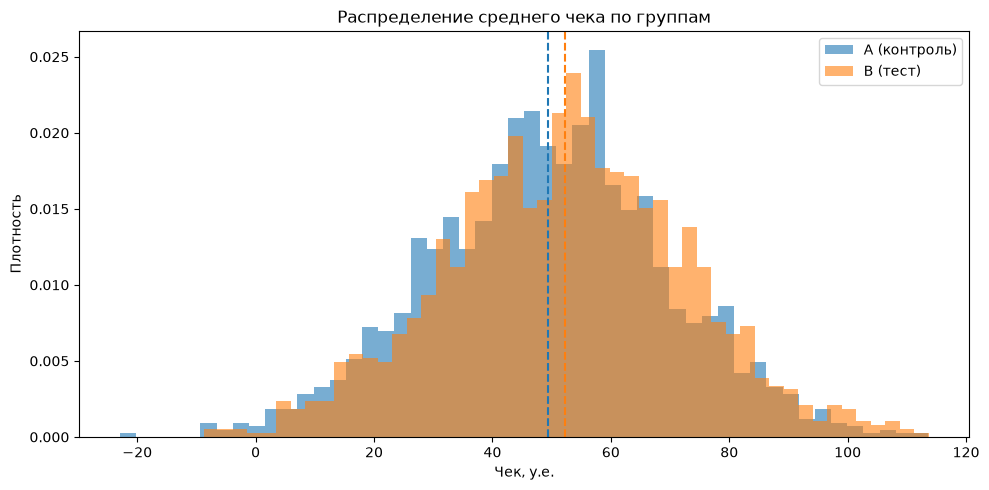

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(group_A, bins=50, alpha=0.6, label='A (контроль)', density=True)
plt.hist(group_B, bins=50, alpha=0.6, label='B (тест)', density=True)
plt.axvline(group_A.mean(), color='C0', linestyle='--')
plt.axvline(group_B.mean(), color='C1', linestyle='--')
plt.title('Распределение среднего чека по группам')
plt.xlabel('Чек, у.е.'); plt.ylabel('Плотность'); plt.legend()
plt.tight_layout(); plt.show()

### 4. Welch t-тест, доверительный интервал и размер эффекта

In [5]:
t_stat, p_value = stats.ttest_ind(group_B, group_A, equal_var=False)

diff = group_B.mean() - group_A.mean()
se = np.sqrt(group_A.var(ddof=1)/len(group_A) + group_B.var(ddof=1)/len(group_B))
ci_low, ci_high = diff - 1.96 * se, diff + 1.96 * se

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp

d = cohens_d(group_B, group_A)

print(f'Welch t-тест: t = {t_stat:.3f}, p-value = {p_value:.4f}')
print(f'Разница B - A: {diff:.3f} у.е.')
print(f'95% ДИ разницы: [{ci_low:.3f}; {ci_high:.3f}]')
print(f"Cohen's d: {d:.3f}")

Welch t-тест: t = 3.999, p-value = 0.0001
Разница B - A: 2.868 у.е.
95% ДИ разницы: [1.462; 4.273]
Cohen's d: 0.143


### 5. Апостериорная мощность

Проверим, какую мощность фактически даёт наш размер выборки при заложенном эффекте.

In [6]:
from statsmodels.stats.power import TTestIndPower
effect_size = true_effect / sigma  # d при истинном эффекте
analysis = TTestIndPower()
power = analysis.power(effect_size=effect_size, nobs1=n, alpha=alpha, alternative='two-sided')
print(f'Размер эффекта (d) при истинном эффекте: {effect_size:.4f}')
print(f'Фактическая мощность теста: {power:.3f}')

Размер эффекта (d) при истинном эффекте: 0.1250
Фактическая мощность теста: 0.938


### Выводы

1. **Дизайн — настоящий A/B-тест:** пользователи распределены по группам случайно, поэтому единственное систематическое различие между A и B — сама тестируемая версия. Это позволяет делать **причинный** вывод (эффект вызван изменением), в отличие от наблюдательных сравнений в Project_1/Project_2, где группы не рандомизированы и возможны конфаундеры.
2. **Результат:** p-value < 0.05 — отвергаем H0. 95% ДИ разницы не содержит нуля и накрывает истинный заложенный эффект (2.5 у.е.), что подтверждает корректность процедуры.
3. **Размер эффекта** (Cohen's d) мал, но эффект стабильно детектируется благодаря заранее рассчитанному размеру выборки под заданный MDE и мощность 80%.
4. **Важно:** размер выборки, MDE и мощность считаются **до** запуска теста — это защищает от подглядывания в данные и p-hacking.